# Importing Libraries and Loading Data
Imports all necessary libraries and loads the dataset.

In [ ]:
import pandas as pd
import numpy as np
import re
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, auc
import warnings
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')

# Loading the dataset into the system
try:
    df = pd.read_csv('Phishing_Email.csv')
    print("Dataset loaded successfully!")
except FileNotFoundError:
    print("Error: 'Phishing_Email.csv' not found.")
    df = pd.DataFrame() 

Dataset loaded successfully!


In [55]:
file_path = "Phishing_Email.csv"
df = pd.read_csv(file_path)


print(df.head())

   Unnamed: 0                                         Email Text  \
0           0  re : 6 . 1100 , disc : uniformitarianism , re ...   
1           1  the other side of * galicismos * * galicismo *...   
2           2  re : equistar deal tickets are you still avail...   
3           3  \nHello I am your hot lil horny toy.\n    I am...   
4           4  software at incredibly low prices ( 86 % lower...   

       Email Type  
0      Safe Email  
1      Safe Email  
2      Safe Email  
3  Phishing Email  
4  Phishing Email  


In [56]:
df

,Unnamed: 0,Email Text,Email Type
0,0,"re : 6 . 1100 , disc : uniformitarianism , re ...",Safe Email
1,1,the other side of * galicismos * * galicismo *...,Safe Email
2,2,re : equistar deal tickets are you still avail...,Safe Email
3,3,\nHello I am your hot lil horny toy.\n I am...,Phishing Email
4,4,software at incredibly low prices ( 86 % lower...,Phishing Email
...,...,...,...
18645,18646,date a lonely housewife always wanted to date ...,Phishing Email
18646,18647,request submitted : access request for anita ....,Safe Email
18647,18648,"re : important - prc mtg hi dorn & john , as y...",Safe Email
18648,18649,press clippings - letter on californian utilit...,Safe Email


In [57]:
empty_data = df [ df ['Email Text'] == 'empty']
print('count of empty datas : ' , len(empty_data))

count of empty datas :  533


<Axes: xlabel='Email Type', ylabel='count'>

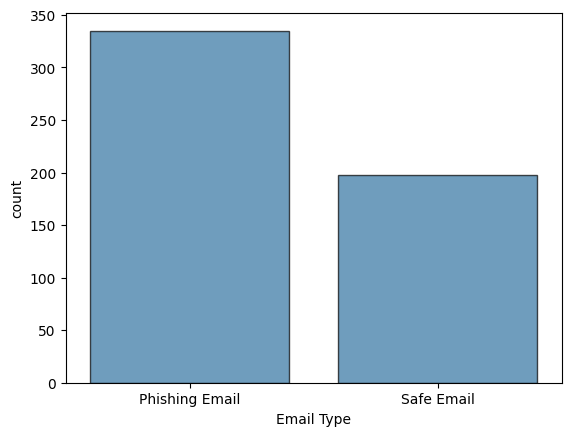

In [58]:
import seaborn as sns

empty_data = df[df['Email Text'] == 'empty']
sns.countplot(data = empty_data, x = 'Email Type', edgecolor = 'black', alpha=0.7)

# Data Preprocessing
Cleaning up the data by dropping unnecessary columns and rows that contain missing values. A function is then defined and used to do this by removing URLs, special characters, and numbers. The labels "Safe Email" and "Phishing Email" are then changed into numerical values 1 and 0.

In [59]:
if not df.empty:
    # Deleting the 'Unnamed: 0' column and rows with null values
    if 'Unnamed: 0' in df.columns:
        df = df.drop(columns=['Unnamed: 0'])
    df.dropna(inplace=True)

    # Removing rows with empty content
    df = df[df['Email Text'] != 'empty']

    # Change 'Email Type' to 1 and 0 (1 for Safe and 0 for Phishing)
    df['Email Type'] = df['Email Type'].map({'Safe Email': 1, 'Phishing Email': 0})

    # Defining the function to clean data
    def clean_text(text):
        text = str(text).lower()  # Turning all text into string and lowercase for ease of use
        text = re.sub(r'\@\w+|\#','', text) # Removes mentions and hashtags
        text = re.sub(r'\d+', '', text) # Removes numbers
        text = re.sub(r'[^\w\s]', '', text) # Removes punctuation
        text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE) # Removes URLs
        return text

    # Calling the function to clean up data
    df['Cleaned Text'] = df['Email Text'].apply(clean_text)

    print("Data preprocessing complete.")
    print(df.head())

Data preprocessing complete.
                                          Email Text  Email Type  \
0  re : 6 . 1100 , disc : uniformitarianism , re ...           1   
1  the other side of * galicismos * * galicismo *...           1   
2  re : equistar deal tickets are you still avail...           1   
3  \nHello I am your hot lil horny toy.\n    I am...           0   
4  software at incredibly low prices ( 86 % lower...           0   

                                        Cleaned Text  
0  re      disc  uniformitarianism  re    sex  la...  
1  the other side of  galicismos   galicismo  is ...  
2  re  equistar deal tickets are you still availa...  
3  \nhello i am your hot lil horny toy\n    i am ...  
4  software at incredibly low prices    lower   d...  


# Splitting the Data
Splitting data into 80% training and 20% testing.

In [60]:
if not df.empty:
    # Defining the features to X and target to y
    X = df['Cleaned Text']
    y = df['Email Type']

    # Splitting data into 80% training and 20% testing
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

    print(f"Data split complete.")
    print(f"Training set size: {len(X_train)} emails")
    print(f"Testing set size: {len(X_test)} emails")

Data split complete.
Training set size: 14480 emails
Testing set size: 3621 emails


# Rule-Based Model Implementation
Simple rule-based algorithm to check if the emails contain certain commonly used phishing words.

In [61]:
# Common phishing keywords related to bank scams
phishing_keywords = [
    'urgent', 'verify', 'account', 'password', 'suspend', 'security', 'login',
    'bank', 'credit', 'card', 'confirm', 'immediately', 'restricted', 'update',
    'access', 'alert', 'claim', 'click', 'winner', 'payment', 'blocked', 'notice',
    'free', 'transfer', 'reset', 'information', 'debit', 'failure', 'identity',
    'locked', 'verify', 'recovery', 'authorization', 'credentials', 'invalid',
    'attention', 'required', 'message', 'sensitive', 'confirm', 'pending',
    'limit', 'action', 'billing', 'refund', 'charge', 'overdue', 'balance',
    'reward', 'exclusive', 'promotion', 'deal', 'discount', 'offer',
    'gift', 'prize', 'congratulations', 'lottery', 'bonus', 'receive',
    'transaction', 'secure', 'protection', 'compliance', 'terms', 'enforcement',
    'reactivate', 'warning', 'threat', 'violation', 'alert', 'failure',
    'form', 'authenticate', 'renew', 'status', 'security', 'locked',
    'notice', 'safety', 'proceed', 'steps', 'follow', 'suspended',
    'risk', 'insurance', 'paypal', 'chase', 'wellsfargo', 'boa',
    'citi', 'hsbc', 'capitalone', 'statement', 'invoice', 'proof',
    'download', 'open', 'attached', 'document', 'login', 'signin', 'support'
]


# Defining the rule-based procedure 
def rule_based_function(email_text):
    # Classifies the emails with phishing keywords to 0 otherwise 1
    for keyword in phishing_keywords:
        if keyword in email_text:
            return 0  # Phishing
    return 1  # Safe

# Applying the function to the testing set
y_pred_rule_based = X_test.apply(rule_based_function)

print("Rule-based procedure complete.")

Rule-based procedure complete.


# Rule-Based Model Evaluation
Finds the accuracy, precision, recall, F1-score, AUC value and ROC curve, and confusion matrix. This is to test its reliability and success.

--- Rule-Based Model Evaluation ---
Accuracy: 0.4297

Classification Report:
              precision    recall  f1-score   support

    Phishing       0.39      0.81      0.52      1396
        Safe       0.61      0.19      0.29      2225

    accuracy                           0.43      3621
   macro avg       0.50      0.50      0.41      3621
weighted avg       0.53      0.43      0.38      3621


Confusion Matrix:
[[1128  268]
 [1797  428]]

AUC Score: 0.50



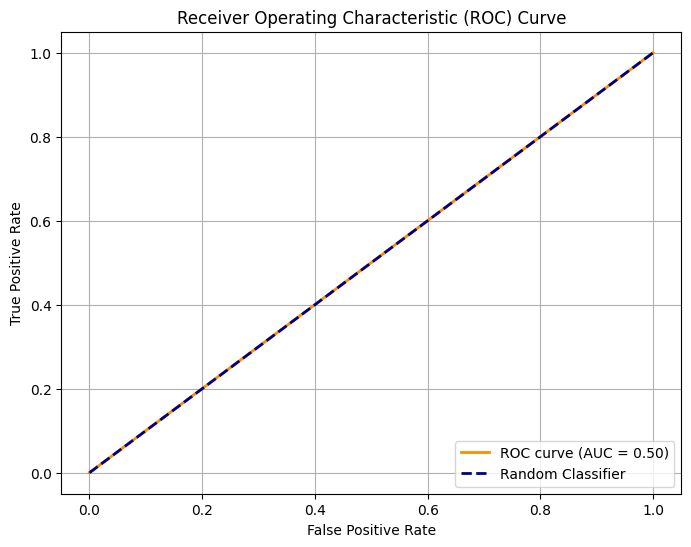

In [62]:
print("--- Rule-Based Model Evaluation ---")

# Calculating metrics
accuracy_rb = accuracy_score(y_test, y_pred_rule_based)
report_rb = classification_report(y_test, y_pred_rule_based, target_names=['Phishing', 'Safe'])
conf_matrix_rb = confusion_matrix(y_test, y_pred_rule_based)
auc_score = roc_auc_score(y_test, y_pred_rule_based)
fpr, tpr, thresholds = roc_curve(y_test, y_pred_rule_based)
roc_auc = auc(fpr, tpr)


# Print the metrics
print(f"Accuracy: {accuracy_rb:.4f}")
print("\nClassification Report:")
print(report_rb)
print("\nConfusion Matrix:")
print(conf_matrix_rb)
print(f"\nAUC Score: {auc_score:.2f}\n")

# Print ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

# Q-Learning - Text Vectorization
As Q-Learning needs numerical input for its states, TfidfVectorizer is used to convert all text data into a matrix of TF-IDF features.

In [63]:
# Initialize the TF-IDF Vectorizer
vectorizer = TfidfVectorizer(max_features=100) # Limited number of features to keep the model simple

# Vectorization on both training and testing data
X_train_vec = vectorizer.fit_transform(X_train).toarray()
X_test_vec = vectorizer.transform(X_test).toarray()

print("Text vectorization for Q-Learning complete.")
print(f"Shape of training vectors: {X_train_vec.shape}")

Text vectorization for Q-Learning complete.
Shape of training vectors: (14480, 100)


# Q-Learning Model Training


In [64]:
# Q-Learning Parameters
alpha = 0.1      # Learning rate
gamma = 0.9      # Discount factor
epsilon = 0.1    # Epsilon for epsilon-greedy strategy
n_episodes = 1000 # Number of training episodes

# Initializing Q-table dimensions (number of states and the number of actions)
# States = number of training samples, Actions = 2 (Phishing/Safe)
n_states = X_train_vec.shape[0]
n_actions = 2
q_table = np.zeros((n_states, n_actions))

# --- Q-Learning Training Loop ---
for episode in range(n_episodes):
    for state_index in range(n_states):
        # Epsilon-greedy action selection
        if np.random.uniform(0, 1) < epsilon:
            action = np.random.choice([0, 1])  # Explore
        else:
            action = np.argmax(q_table[state_index, :]) # Exploit

        # Get reward: +1 for correct, -1 for incorrect
        reward = 1 if action == y_train.iloc[state_index] else -1

        # Q-table update rule
        old_value = q_table[state_index, action]
        next_max = np.max(q_table[state_index, :])
        new_value = old_value + alpha * (reward + gamma * next_max - old_value)
        q_table[state_index, action] = new_value

    if (episode + 1) % 100 == 0:
      print(f"Q-Learning training... Episode {episode + 1}/{n_episodes}")

print("\nQ-Learning model training complete.")

Q-Learning training... Episode 100/1000
Q-Learning training... Episode 200/1000
Q-Learning training... Episode 300/1000
Q-Learning training... Episode 400/1000
Q-Learning training... Episode 500/1000
Q-Learning training... Episode 600/1000
Q-Learning training... Episode 700/1000
Q-Learning training... Episode 800/1000
Q-Learning training... Episode 900/1000
Q-Learning training... Episode 1000/1000

Q-Learning model training complete.


# Q-table

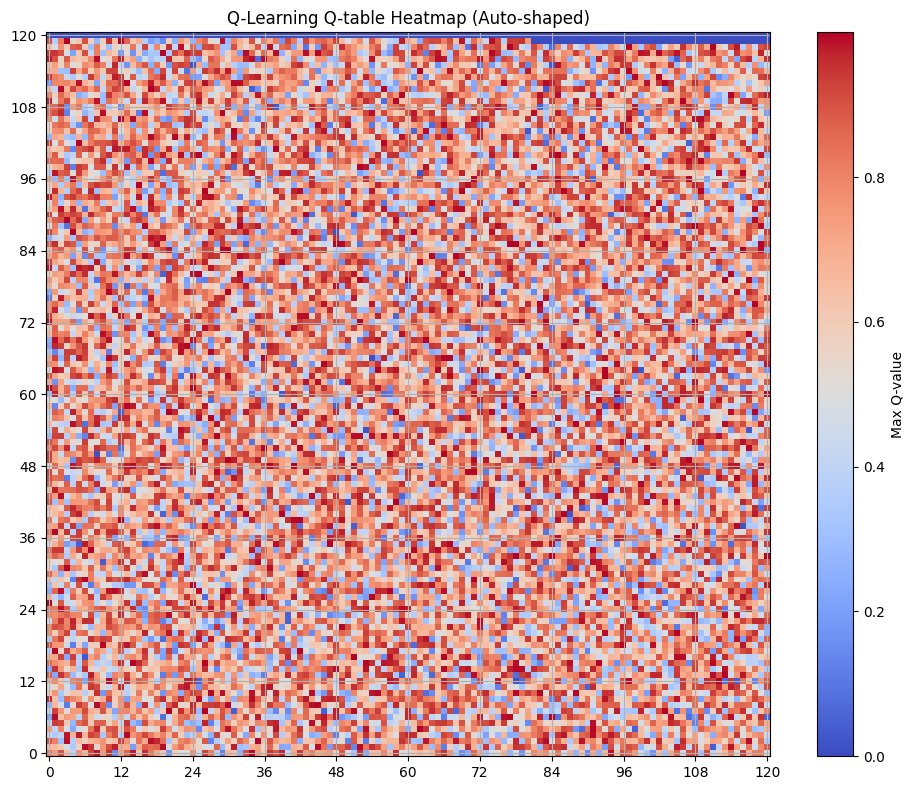

In [76]:
import math

Q_table = np.random.rand(14480, 2)

# Set up Q-table shape
n_states = Q_table.shape[0]
side = int(math.ceil(math.sqrt(n_states)))  # smallest side >= sqrt(n_states)

# Pad Q-table due to its abnormal shape
pad_size = side**2 - n_states
if pad_size > 0:
    Q_table_padded = np.vstack([Q_table, np.zeros((pad_size, 2))])
else:
    Q_table_padded = Q_table

# Max value per state
q_values_grid = np.max(Q_table_padded, axis=1).reshape((side, side))

# Plot heatmap
plt.figure(figsize=(10, 8))
plt.imshow(q_values_grid, cmap='coolwarm', interpolation='nearest')
plt.colorbar(label='Max Q-value')
plt.title('Q-Learning Q-table Heatmap (Auto-shaped)')
plt.xticks(np.arange(0, side, step=side//10 or 1))
plt.yticks(np.arange(0, side, step=side//10 or 1))
plt.gca().invert_yaxis()
plt.grid(True)

plt.tight_layout()
plt.show()


# Q-Learning Model Prediction & Evaluation
Using the trained Q-table, the model is now used to make predictions using the testing data set. 

--- Q-Learning Model Evaluation ---
Accuracy: 0.9111

Classification Report:
              precision    recall  f1-score   support

    Phishing       0.88      0.89      0.88      1396
        Safe       0.93      0.93      0.93      2225

    accuracy                           0.91      3621
   macro avg       0.91      0.91      0.91      3621
weighted avg       0.91      0.91      0.91      3621


Confusion Matrix:
[[1236  160]
 [ 162 2063]]

AUC Score: 0.91



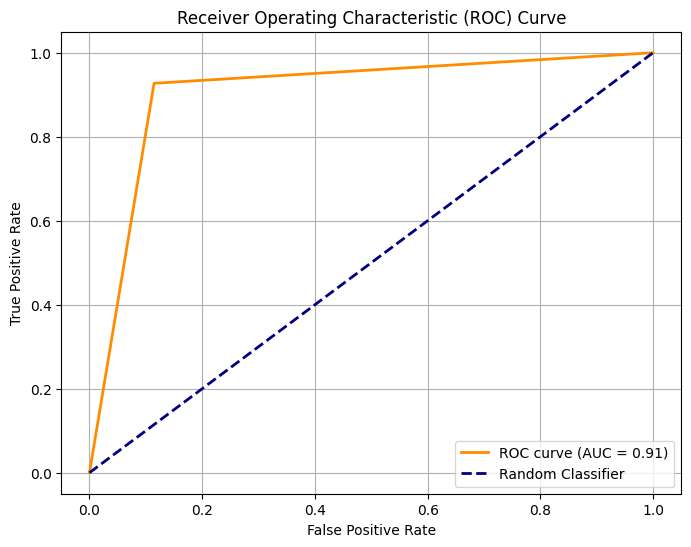

In [65]:
# --- Prediction on the test set ---
y_pred_q_learning = []

# For each test sample, find the most similar training sample to determine the state and then use the Q-table to predict the action.
from sklearn.metrics.pairwise import cosine_similarity

for test_vec in X_test_vec:
    # Find the most similar state from the training data
    similarities = cosine_similarity(test_vec.reshape(1, -1), X_train_vec)
    best_state_index = np.argmax(similarities)
    
    # Predict action based on the learned Q-table for that state
    action = np.argmax(q_table[best_state_index, :])
    y_pred_q_learning.append(action)


print("--- Q-Learning Model Evaluation ---")

# Calculate metrics
accuracy_ql = accuracy_score(y_test, y_pred_q_learning)
report_ql = classification_report(y_test, y_pred_q_learning, target_names=['Phishing', 'Safe'])
conf_matrix_ql = confusion_matrix(y_test, y_pred_q_learning)
auc_score = roc_auc_score(y_test, y_pred_q_learning)
fpr, tpr, thresholds = roc_curve(y_test, y_pred_q_learning)
roc_auc = auc(fpr, tpr)


# Print metrics
print(f"Accuracy: {accuracy_ql:.4f}")
print("\nClassification Report:")
print(report_ql)
print("\nConfusion Matrix:")
print(conf_matrix_ql)
print(f"\nAUC Score: {auc_score:.2f}\n")

#Print ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

# Model Performance Comparison

In [70]:
from sklearn.metrics import precision_recall_fscore_support

# --- Compare Models ---

# Calculate all metrics for the Rule-Based Model
accuracy_rb = accuracy_score(y_test, y_pred_rule_based)
p_rb, r_rb, f1_rb, _ = precision_recall_fscore_support(y_test, y_pred_rule_based, labels=[0, 1])

# Calculate all metrics for the Q-Learning Model
accuracy_ql = accuracy_score(y_test, y_pred_q_learning)
p_ql, r_ql, f1_ql, _ = precision_recall_fscore_support(y_test, y_pred_q_learning, labels=[0, 1], zero_division=0)


# Comparing the score for the Phishing class (index 0)
comparison_data = {
    "Metric": ["Accuracy", "Phishing Precision", "Phishing Recall", "Phishing F1-Score"],
    "Rule-Based Model": [accuracy_rb, p_rb[0], r_rb[0], f1_rb[0]],
    "Q-Learning Model": [accuracy_ql, p_ql[0], r_ql[0], f1_ql[0]],
    "Difference": [
        accuracy_ql - accuracy_rb,
        p_ql[0] - p_rb[0],
        r_ql[0] - r_rb[0],
        f1_ql[0] - f1_rb[0]
    ]
}

comparison_df = pd.DataFrame(comparison_data)
comparison_df = comparison_df.set_index("Metric")

print("--- Model Performance Comparison ---")
display(comparison_df)

--- Model Performance Comparison ---


,Rule-Based Model,Q-Learning Model,Difference
Metric,,,
Accuracy,0.429716,0.911074,0.481359
Phishing Precision,0.385641,0.884120,0.498479
Phishing Recall,0.808023,0.885387,0.077364
Phishing F1-Score,0.522101,0.884753,0.362652


In [68]:
# --- Display Sample Predictions ---

print("--- Testing Models on a Random Sample of Emails ---\n")

# Combine test data and predictions into a single DataFrame for easier sampling
results_df = pd.DataFrame({
    'Email Text': X_test,
    'Actual Label': y_test,
    'Rule-Based Prediction': y_pred_rule_based,
    'Q-Learning Prediction': y_pred_q_learning
})

# Define a mapping from numerical labels back to text for clarity
label_map = {1: 'Safe Email', 0: 'Phishing Email'}

# Take a random sample from the results. 
# Removing 'random_state' ensures a different sample is chosen each time.
sample_emails = results_df.sample(1) 

# Iterate through the samples and print the results
for index, row in sample_emails.iterrows():
    print(f"--- Sample Email #{index} ---")
    
    # Print the original email text (first 500 characters for brevity)
    print(f"Email Text: \n{row['Email Text'][:500]}...\n")
    
    # Print the actual vs. predicted labels
    print(f"\tActual Label: \t\t{label_map[row['Actual Label']]}")
    print(f"\tRule-Based Prediction: \t{label_map[row['Rule-Based Prediction']]}")
    print(f"\tQ-Learning Prediction: \t{label_map[row['Q-Learning Prediction']]}")
    print("-" * 30 + "\n")

--- Testing Models on a Random Sample of Emails ---

--- Sample Email #7843 ---
Email Text: 
gaim official aptrpm repositorys gaim
rpm  redhateni release
rpmsrc  redhateni releasethought i should post that one too just fell over it bye
che_______________________________________________
rpmlist mailing list 

...

	Actual Label: 		Safe Email
	Rule-Based Prediction: 	Safe Email
	Q-Learning Prediction: 	Phishing Email
------------------------------

